# AI Translation Pipeline — Multi-Language Round-Trip (Qwen3-4B-Instruct-2507)
Loads 500 rows from `syvai/finetranslations-chat-da`, round-trip translates English → X → English for 6 target languages (Spanish, Korean, Chinese, Swahili, Maltese, German) using **Qwen3-4B-Instruct-2507** running locally on GPU, scores quality with BLEU / chrF / BERTScore, and compares across languages.

> **Google Colab**: Run on a GPU runtime (Runtime → Change runtime type → T4 GPU). The model is loaded in 4-bit quantization (~2–3 GB VRAM).

## Data

Streams 500 rows from [`syvai/finetranslations-chat-da`](https://huggingface.co/datasets/syvai/finetranslations-chat-da) on HuggingFace. Each row contains a `messages` list with `role`/`content` pairs — we extract only the `user` messages, which are the original English texts. These same source sentences are used as input for all 6 language round-trips.

In [1]:
import sys
!{sys.executable} -m pip install -U transformers accelerate bitsandbytes datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 125.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.2 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import itertools
import torch
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/Coding project/Qwen_Translations"

# Create output directories immediately
os.makedirs(f"{BASE_DIR}/lang_results_qwen/checkpoints", exist_ok=True)

# ============================================================
# CONFIGURATION — adjust these for testing vs full runs
# ============================================================
TEST_MODE = False          # Set to False for a full run
NUM_ROWS = 20 if TEST_MODE else 500          # Number of source texts to use
NUM_LANGUAGES = 1 if TEST_MODE else 6        # Number of languages to translate
# ============================================================

MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

# Target languages for round-trip translation
ALL_LANGUAGES = {
    "Spanish": "es",
    "Korean":  "ko",
    "Chinese": "zh",
    "Swahili": "sw",
    "Maltese": "mt",
    "German": "de",
}

# Select subset based on NUM_LANGUAGES
LANGUAGES = dict(list(ALL_LANGUAGES.items())[:NUM_LANGUAGES])

# Load model in 4-bit quantization to fit comfortably on a T4 GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

print(f"Model loaded: {MODEL_ID}")
print(f"Device: {model.device}")
print(f"TEST_MODE: {TEST_MODE} — {NUM_ROWS} rows, {NUM_LANGUAGES} language(s): {list(LANGUAGES.keys())}")
print(f"Output dirs created: {BASE_DIR}/lang_results_qwen/, {BASE_DIR}/lang_results_qwen/checkpoints/")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Model loaded: Qwen/Qwen3-4B-Instruct-2507
Device: cuda:0
TEST_MODE: False — 500 rows, 6 language(s): ['Spanish', 'Korean', 'Chinese', 'Swahili', 'Maltese', 'German']
Output dirs created: /content/drive/MyDrive/Coding project/Qwen_Translations/lang_results_qwen/, /content/drive/MyDrive/Coding project/Qwen_Translations/lang_results_qwen/checkpoints/


In [3]:
# Load rows using streaming (avoids downloading the full dataset)
stream = load_dataset("syvai/finetranslations-chat-da", split="train", streaming=True)
df_raw = pd.DataFrame(itertools.islice(stream, NUM_ROWS))

print(df_raw.shape)
print("\nSample row (messages structure):")
print(df_raw["messages"][0])

README.md:   0%|          | 0.00/326 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/421 [00:00<?, ?it/s]

(500, 1)

Sample row (messages structure):
[{'content': "The Jysk billionaire Lars Larsen has finally been allowed to expand his empire.\nThe Danish Competition and Consumer Authority today approved Larsen's takeover of furniture trading house Actona.\nLars Larsen and Actona completed the deal back in April last year and…\nPhoto: Scanpix\nCompanies By Bjarne Bang\nWould you like to learn more about strategy and leadership? The Børsen Executive Club is back, giving you inspiration and concrete tools. Interested? Click here and read more.", 'role': 'user'}, {'content': 'Jysk-milliardæren Lars Larsen har endelig fåret lov at udvide sit imperium.\nKonkurrence- og Forbrugerstyrelsen har i dag godkendt Larsens overtagelse af møbelhandelshuset Actona.\nLars Larsen og Actona sluttede handelen tilbage i april i fjor og...\nFoto: Scanpix\nVirksomheder Af Bjarne Bang\nVil du blive klogere på strategi og ledelse? Børsen Executive Club er tilbage, og giver dig inspiration og konkrete værktøjer. Int

In [4]:
# Extract English user content from messages into a plain list
def extract_user_content(messages):
    for msg in messages:
        if msg.get("role") == "user":
            return msg["content"]
    return None

english_texts = (
    df_raw["messages"]
    .apply(extract_user_content)
    .dropna()
    .reset_index(drop=True)
    .tolist()
)

print(f"Extracted {len(english_texts)} English source texts")

Extracted 500 English source texts


## Translation

Round-trip translation using **Qwen3-4B-Instruct-2507**: English → X → English for each of the 6 target languages. Inference runs sequentially on GPU (no API rate limits to worry about). Per-language results are saved to `lang_results_qwen/` as they complete, so a crash mid-run can be resumed without repeating completed languages.

In [5]:
MAX_NEW_TOKENS = 512
BATCH_SIZE = 12  # process 24 texts at once; fits comfortably on T4 with 4-bit model

# Set pad token if not already defined
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Batched generation needs left-padding for decoder-only models
tokenizer.padding_side = "left"


def build_prompt(text, source_lang, target_lang):
    """Build a chat-formatted prompt string (no tokenization yet)."""
    messages = [
        {
            "role": "system",
            "content": (
                f"You are a professional translator. "
                f"Translate the following text from {source_lang} to {target_lang}. "
                f"Return only the translated text, nothing else."
            ),
        },
        {"role": "user", "content": text},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def translate_batch(texts, source_lang, target_lang):
    """Translate a list of texts in a single batched forward pass."""
    prompts = [build_prompt(t, source_lang, target_lang) for t in texts]
    inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the new tokens for each item in the batch
    results = []
    for seq in output_ids:
        new_tokens = seq[input_len:]
        results.append(tokenizer.decode(new_tokens, skip_special_tokens=True).strip())
    return results


print(f"Batch size: {BATCH_SIZE}")

Batch size: 12


In [6]:
import time
import json
import shutil

DRIVE_CHECKPOINT_DIR = f"{BASE_DIR}/lang_results_qwen/checkpoints"
LOCAL_CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

def _local_checkpoint_path(language, pass_num):
    return os.path.join(LOCAL_CHECKPOINT_DIR, f"{language.lower()}_pass{pass_num}.json")

def _drive_checkpoint_path(language, pass_num):
    return os.path.join(DRIVE_CHECKPOINT_DIR, f"{language.lower()}_pass{pass_num}.json")

def _save_checkpoint(language, pass_num, results, to_drive=False):
    local_path = _local_checkpoint_path(language, pass_num)
    with open(local_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False)

    if to_drive:
        drive_path = _drive_checkpoint_path(language, pass_num)
        shutil.copy2(local_path, drive_path)

def _load_checkpoint(language, pass_num):
    local_path = _local_checkpoint_path(language, pass_num)
    drive_path = _drive_checkpoint_path(language, pass_num)

    if os.path.exists(local_path):
        with open(local_path, "r", encoding="utf-8") as f:
            return json.load(f)
    elif os.path.exists(drive_path):
        with open(drive_path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

def _clear_checkpoints(language):
    for p in [1, 2]:
        for path in [_local_checkpoint_path(language, p), _drive_checkpoint_path(language, p)]:
            if os.path.exists(path):
                os.remove(path)

def translate_language(texts, language):
    """Round-trip translate all texts for one language with batch-level checkpoints."""
    n = len(texts)

    # --- Pass 1: EN → target language (with checkpoint resume) ---
    translated_all = _load_checkpoint(language, 1) or []
    resume_from = len(translated_all)
    if resume_from > 0:
        print(f"  Resuming Pass 1 from item {resume_from}/{n}")

    print(f"  Pass 1/2: English → {language}")
    for start in range(resume_from, n, BATCH_SIZE):
        batch = texts[start : start + BATCH_SIZE]
        results = translate_batch(batch, "English", language)
        translated_all.extend(results)
        for j, (src, tgt) in enumerate(zip(batch, results)):
            print(f"  [{start+j+1}/{n}] EN: {src[:60]!r}")
            print(f"     → {language}: {tgt[:60]!r}")

        to_drive = len(translated_all) % 100 < BATCH_SIZE or len(translated_all) == n
        _save_checkpoint(language, 1, translated_all, to_drive=to_drive)
    print()

    # --- Pass 2: target language → EN (with checkpoint resume) ---
    back_all = _load_checkpoint(language, 2) or []
    resume_from = len(back_all)
    if resume_from > 0:
        print(f"  Resuming Pass 2 from item {resume_from}/{n}")

    print(f"  Pass 2/2: {language} → English")
    for start in range(resume_from, n, BATCH_SIZE):
        batch = translated_all[start : start + BATCH_SIZE]
        results = translate_batch(batch, language, "English")
        back_all.extend(results)
        for j, (tgt, back) in enumerate(zip(batch, results)):
            print(f"  [{start+j+1}/{n}] {language}: {tgt[:60]!r}")
            print(f"     → EN: {back[:60]!r}")

        to_drive = len(back_all) % 100 < BATCH_SIZE or len(back_all) == n
        _save_checkpoint(language, 2, back_all, to_drive=to_drive)
    print()

    _clear_checkpoints(language)
    return translated_all, back_all

In [7]:
all_results = []

for language in LANGUAGES:
    out_path = f"{BASE_DIR}/lang_results_qwen/{language.lower()}.csv"

    # Resume support: skip if this language was already translated
    if os.path.exists(out_path):
        print(f"Skipping {language} — loading {out_path}")
        all_results.append(pd.read_csv(out_path))
        continue

    print(f"\n{'='*60}")
    print(f"Translating EN → {language} → EN  ({len(english_texts)} rows)")
    print(f"{'='*60}")

    t0 = time.time()
    translated_col, back_col = translate_language(english_texts, language)
    elapsed = time.time() - t0

    lang_df = pd.DataFrame({
        "english_original": english_texts,
        "language":         language,
        "translated":       translated_col,
        "back_translated":  back_col,
    })
    lang_df.to_csv(out_path, index=False)
    all_results.append(lang_df)
    print(f"{language} complete — {lang_df['translated'].notna().sum()} rows in {elapsed:.0f}s")

df = pd.concat(all_results, ignore_index=True)
print(f"\nTotal rows: {len(df)}")
print(df["language"].value_counts())
df.head(10)

Skipping Spanish — loading /content/drive/MyDrive/Coding project/Qwen_Translations/lang_results_qwen/spanish.csv
Skipping Korean — loading /content/drive/MyDrive/Coding project/Qwen_Translations/lang_results_qwen/korean.csv
Skipping Chinese — loading /content/drive/MyDrive/Coding project/Qwen_Translations/lang_results_qwen/chinese.csv

Translating EN → Swahili → EN  (500 rows)
  Resuming Pass 1 from item 500/500
  Pass 1/2: English → Swahili

  Resuming Pass 2 from item 300/500
  Pass 2/2: Swahili → English
  [301/500] Swahili: 'Kuwa na kitu na kila muda, na kumaliza kwa muda.  \nKujaribu '
     → EN: 'To have a certain number of units at each time, to try on a '
  [302/500] Swahili: '5.569  \nKama amewakilisha mizani ya La Liga kwa muda mmoja, '
     → EN: '5,569  \nIf a team represents La Liga for one season, it is c'
  [303/500] Swahili: 'Sukima ya kisasa kwa maelekezo - Mfano ya ujumbe wa kutosha '
     → EN: 'A sample of a situation - Example of a situation, a situatio'
  [304/500

,english_original,language,translated,back_translated
0,The Jysk billionaire Lars Larsen has finally b...,Spanish,"El millonario danés Jysk, Lars Larsen, finalme...",The Danish millionaire Lars Larsen has finally...
1,I need my hedge trimmed in my allotment garden...,Spanish,Necesito que se corte mi arbusto en el jardín ...,I need my shrub cut in the garden of my plot i...
2,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Spanish,Funhouse Katsuragawa \nFunhouse Katsuragawa o...,Funhouse Katsuragawa \nFunhouse Katsuragawa o...
3,fyens.dk uses cookies to give you a good exper...,Spanish,Los vecinos en dificultad junto al nido en Hin...,The struggling neighbors near the nest at Hine...
4,THE NEWSPAPER\nMorgan Motor Company is the wor...,Spanish,EL PERIÓDICO \nMorgan Motor Company es la mar...,THE PERIODICAL \nMorgan Motor Company is the ...
5,This luxurious mansion is situated surrounded ...,Spanish,Esta lujosa mansión se encuentra situada en el...,This luxurious mansion is located in the heart...
6,For travelers who want to experience the sight...,Spanish,Para los viajeros que desean experimentar la v...,For travelers who want to experience the sight...
7,With a convenient location in Cavaion Veronese...,Spanish,"Con una ubicación cómoda en Cavaion Veronese, ...",Located in a convenient spot in Cavaion Verone...
8,Lamps and Lanterns\nTo get the most out of you...,Spanish,Lámparas y faroles \nPara aprovechar al máxim...,Lamps and lanterns \nTo make the most of your...
9,Quiet location below the vineyards. The center...,Spanish,Ubicación tranquila bajo los viñedos. El centr...,Quiet location under vineyards. The center of ...


In [8]:
# Save raw translations (before scoring) — analysis section can be re-run from here
df.to_csv(f"{BASE_DIR}/translations_qwen.csv", index=False)
print(f"Saved {len(df)} rows to {BASE_DIR}/translations_qwen.csv")
df.head()

Saved 3000 rows to /content/drive/MyDrive/Coding project/Qwen_Translations/translations_qwen.csv


,english_original,language,translated,back_translated
0,The Jysk billionaire Lars Larsen has finally b...,Spanish,"El millonario danés Jysk, Lars Larsen, finalme...",The Danish millionaire Lars Larsen has finally...
1,I need my hedge trimmed in my allotment garden...,Spanish,Necesito que se corte mi arbusto en el jardín ...,I need my shrub cut in the garden of my plot i...
2,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Spanish,Funhouse Katsuragawa \nFunhouse Katsuragawa o...,Funhouse Katsuragawa \nFunhouse Katsuragawa o...
3,fyens.dk uses cookies to give you a good exper...,Spanish,Los vecinos en dificultad junto al nido en Hin...,The struggling neighbors near the nest at Hine...
4,THE NEWSPAPER\nMorgan Motor Company is the wor...,Spanish,EL PERIÓDICO \nMorgan Motor Company es la mar...,THE PERIODICAL \nMorgan Motor Company is the ...


## Analysis

Compares `english_original` against `back_translated` using three complementary metrics:

- **BLEU** — word n-gram overlap (0–100). Good baseline but sensitive to text length.
- **chrF** — character n-gram F-score (0–100). More robust to paraphrasing and length variation.
- **BERTScore** — semantic similarity via RoBERTa embeddings (0–1). Captures meaning even when wording differs.

Scores are computed per language group and compared across all 6 languages.

> Start here if you only want to re-run the analysis without repeating the translations.

In [9]:
# Free GPU memory from the translation model before loading BERTScore
import gc
try:
    del model
    del tokenizer
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed for scoring phase")

GPU memory freed for scoring phase


In [10]:
# Load translations from CSV — start here to re-run analysis without repeating inference
import pandas as pd
df = pd.read_csv(f"{BASE_DIR}/translations_qwen.csv")
print(f"Loaded {len(df)} rows across {df['language'].nunique()} languages")
print(df["language"].value_counts())
df.head()

Loaded 3000 rows across 6 languages
language
Spanish    500
Korean     500
Chinese    500
Swahili    500
Maltese    500
German     500
Name: count, dtype: int64


,english_original,language,translated,back_translated
0,The Jysk billionaire Lars Larsen has finally b...,Spanish,"El millonario danés Jysk, Lars Larsen, finalme...",The Danish millionaire Lars Larsen has finally...
1,I need my hedge trimmed in my allotment garden...,Spanish,Necesito que se corte mi arbusto en el jardín ...,I need my shrub cut in the garden of my plot i...
2,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Spanish,Funhouse Katsuragawa \nFunhouse Katsuragawa o...,Funhouse Katsuragawa \nFunhouse Katsuragawa o...
3,fyens.dk uses cookies to give you a good exper...,Spanish,Los vecinos en dificultad junto al nido en Hin...,The struggling neighbors near the nest at Hine...
4,THE NEWSPAPER\nMorgan Motor Company is the wor...,Spanish,EL PERIÓDICO \nMorgan Motor Company es la mar...,THE PERIODICAL \nMorgan Motor Company is the ...


In [11]:
import sys
!{sys.executable} -m pip install sacrebleu bert-score matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00


In [12]:
import sacrebleu
from bert_score import score as bert_score

# Sentence-level BLEU and chrF (row-by-row)
df["bleu"] = df.apply(
    lambda r: sacrebleu.sentence_bleu(r["back_translated"], [r["english_original"]]).score, axis=1
)
df["chrf"] = df.apply(
    lambda r: sacrebleu.sentence_chrf(r["back_translated"], [r["english_original"]]).score, axis=1
)

# BERTScore — batched per language (lang="en" because we score EN back-translations vs EN originals)
bert_p_all = pd.Series(index=df.index, dtype=float)
bert_r_all = pd.Series(index=df.index, dtype=float)
bert_f_all = pd.Series(index=df.index, dtype=float)

for language, group in df.groupby("language"):
    print(f"BERTScore: {language} ({len(group)} rows)...")
    P, R, F1 = bert_score(
        group["back_translated"].tolist(),
        group["english_original"].tolist(),
        lang="en", verbose=False
    )
    bert_p_all.loc[group.index] = P.numpy()
    bert_r_all.loc[group.index] = R.numpy()
    bert_f_all.loc[group.index] = F1.numpy()

df["bertscore_precision"] = bert_p_all
df["bertscore_recall"]    = bert_r_all
df["bertscore_f1"]        = bert_f_all

# Summary table
summary = df.groupby("language")[["bleu", "chrf", "bertscore_f1"]].mean().round(3)
print("\n=== Mean scores per language ===")
print(summary.to_string())

BERTScore: Chinese (500 rows)...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore: Swahili (500 rows)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Mean scores per language ===
            bleu    chrf  bertscore_f1
language                              
Chinese   22.389  56.000         0.911
German    36.064  63.162         0.929
Korean    17.965  49.821         0.900
Maltese    1.669  12.195         0.739
Spanish   38.925  65.233         0.932
Swahili    2.097  14.417         0.748


In [13]:
# Save full results including scores
df.to_csv(f"{BASE_DIR}/translations_qwen.csv", index=False)
print(f"Saved {len(df)} rows to {BASE_DIR}/translations_qwen.csv")
df[["language", "english_original", "back_translated", "bleu", "chrf", "bertscore_f1"]].head(10)

Saved 3000 rows to /content/drive/MyDrive/Coding project/Qwen_Translations/translations_qwen.csv


,language,english_original,back_translated,bleu,chrf,bertscore_f1
0,Spanish,The Jysk billionaire Lars Larsen has finally b...,The Danish millionaire Lars Larsen has finally...,44.674248,71.362843,0.950315
1,Spanish,I need my hedge trimmed in my allotment garden...,I need my shrub cut in the garden of my plot i...,32.892464,56.756164,0.953896
2,Spanish,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Funhouse Katsuragawa \nFunhouse Katsuragawa o...,58.390770,79.139718,0.957647
3,Spanish,fyens.dk uses cookies to give you a good exper...,The struggling neighbors near the nest at Hine...,4.039635,33.026850,0.892036
4,Spanish,THE NEWSPAPER\nMorgan Motor Company is the wor...,THE PERIODICAL \nMorgan Motor Company is the ...,50.772154,69.466609,0.940464
5,Spanish,This luxurious mansion is situated surrounded ...,This luxurious mansion is located in the heart...,33.735908,64.388798,0.957016
6,Spanish,For travelers who want to experience the sight...,For travelers who want to experience the sight...,66.823936,79.884131,0.973040
7,Spanish,With a convenient location in Cavaion Veronese...,Located in a convenient spot in Cavaion Verone...,70.565120,84.845220,0.971729
8,Spanish,Lamps and Lanterns\nTo get the most out of you...,Lamps and lanterns \nTo make the most of your...,26.076512,53.336744,0.942058
9,Spanish,Quiet location below the vineyards. The center...,Quiet location under vineyards. The center of ...,45.118139,72.878032,0.923629


## Visualisation

Five-panel plot comparing translation quality across all 6 languages:
- **Row 1**: Distribution of BLEU, chrF, and BERTScore F1 per language (box plots with annotated means)
- **Row 2**: Normalized mean scores per language (bar chart), and chrF vs BERTScore F1 scatter coloured by language

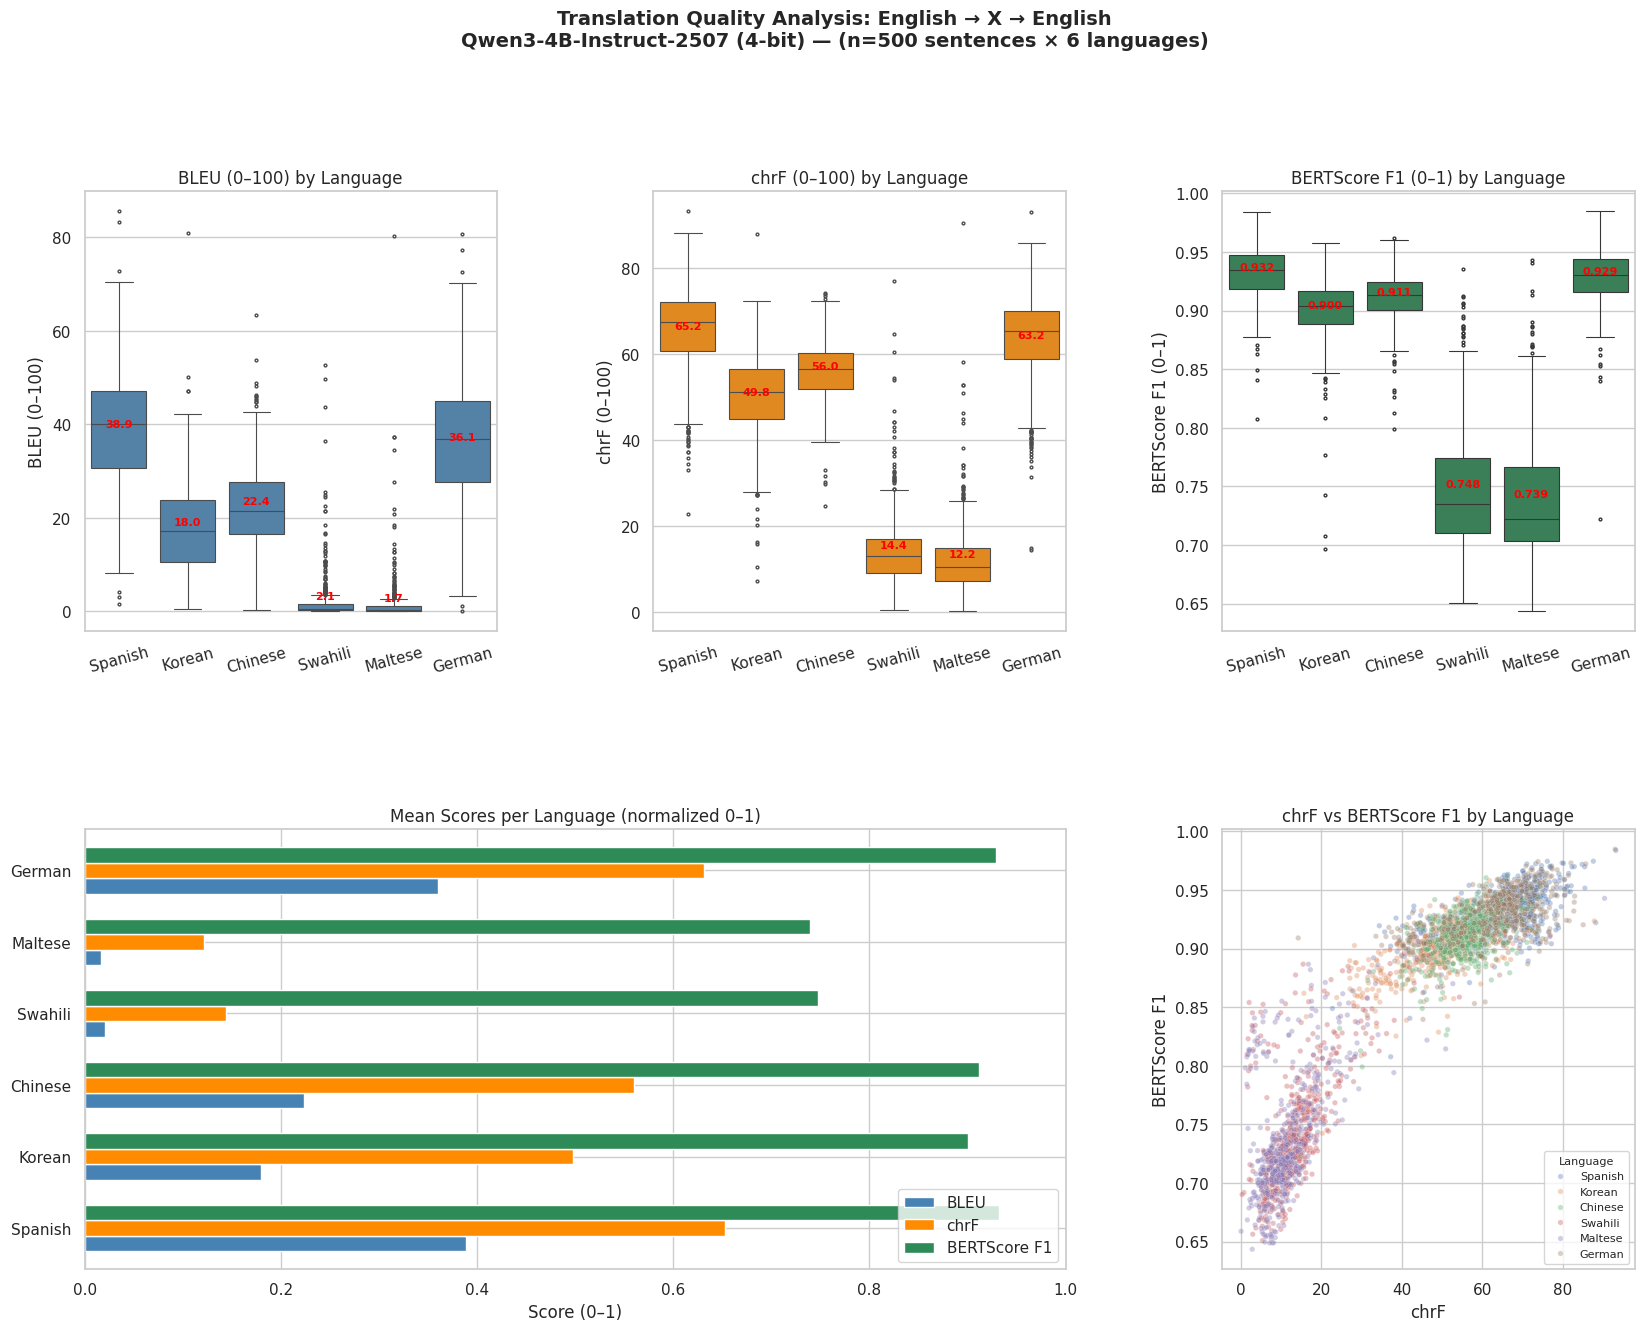

Saved to /content/drive/MyDrive/Coding project/Qwen_Translations/translation_quality_qwen.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid")
LANGUAGE_ORDER = list(LANGUAGES.keys())

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

METRICS = [
    ("bleu",         "BLEU (0\u2013100)",       "steelblue"),
    ("chrf",         "chrF (0\u2013100)",        "darkorange"),
    ("bertscore_f1", "BERTScore F1 (0\u20131)",  "seagreen"),
]

# Row 1: Box plot per metric, language on x-axis
for col, (metric, xlabel, color) in enumerate(METRICS):
    ax = fig.add_subplot(gs[0, col])
    sns.boxplot(
        data=df, x="language", y=metric,
        order=LANGUAGE_ORDER, color=color,
        fliersize=2, linewidth=0.8, ax=ax,
    )
    means = df.groupby("language")[metric].mean()
    fmt = ".1f" if metric != "bertscore_f1" else ".3f"
    for j, lang in enumerate(LANGUAGE_ORDER):
        ax.text(j, means[lang], f"{means[lang]:{fmt}}",
                ha="center", va="bottom", fontsize=8, color="red", fontweight="bold")
    ax.set_title(f"{xlabel} by Language")
    ax.set_xlabel("")
    ax.set_ylabel(xlabel)
    ax.tick_params(axis="x", rotation=15)

# Row 2, col 0-1: Normalized mean scores horizontal bar chart
ax4 = fig.add_subplot(gs[1, 0:2])
means_df = df.groupby("language")[["bleu", "chrf", "bertscore_f1"]].mean()
means_norm = means_df.copy()
means_norm["bleu"] = means_norm["bleu"] / 100
means_norm["chrf"] = means_norm["chrf"] / 100
means_norm = means_norm.loc[LANGUAGE_ORDER]
means_norm.plot(kind="barh", ax=ax4,
                color=["steelblue", "darkorange", "seagreen"],
                width=0.65, edgecolor="white")
ax4.set_title("Mean Scores per Language (normalized 0\u20131)")
ax4.set_xlabel("Score (0\u20131)")
ax4.set_ylabel("")
ax4.legend(["BLEU", "chrF", "BERTScore F1"], loc="lower right")
ax4.set_xlim(0, 1)

# Row 2, col 2: chrF vs BERTScore F1 scatter, hue=language
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(
    data=df, x="chrf", y="bertscore_f1",
    hue="language", hue_order=LANGUAGE_ORDER,
    alpha=0.35, s=15, ax=ax5,
)
ax5.set_title("chrF vs BERTScore F1 by Language")
ax5.set_xlabel("chrF")
ax5.set_ylabel("BERTScore F1")
ax5.legend(title="Language", fontsize=8, title_fontsize=8)

n_per_lang = len(df) // len(LANGUAGES)
plt.suptitle(
    f"Translation Quality Analysis: English \u2192 X \u2192 English\n"
    f"Qwen3-4B-Instruct-2507 (4-bit) \u2014 "
    f"(n={n_per_lang} sentences \u00d7 {len(LANGUAGES)} languages)",
    fontsize=14, fontweight="bold", y=1.01
)

plot_path = f"{BASE_DIR}/translation_quality_qwen.png"
plt.savefig(plot_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to {plot_path}")